---
title: earthkit-meteo: thermo
short_title: Thermo
---

## Earthkit-meteo: thermodynamics

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/jupyter-notebook-template/main?labpath=jupyter-notebook-template-copernicus.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/jupyter-notebook-template/blob/main/jupyter-notebook-template-copernicus.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/jupyter-notebook-template/blob/main/jupyter-notebook-template-copernicus.ipynb)

### Getting the input data

In [1]:
import earthkit.data as ekd
from earthkit.meteo import thermo
import earthkit.plots as ekp

ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
ds

<xarray.Dataset> Size: 35MB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 301,
                     longitude: 601)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
    number          int64 8B ...
    expver          (valid_time) <U4 64B dask.array<chunksize=(4,), meta=np.ndarray>
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

### Potential temperature

In [2]:
# input: temperature and pressure dataarrays
theta = thermo.potential_temperature(ds.t, ds.pressure_level)
theta

<xarray.DataArray 't' (valid_time: 4, pressure_level: 3, latitude: 301,
                       longitude: 601)> Size: 17MB
dask.array<transpose, shape=(4, 3, 301, 601), dtype=float64, chunksize=(4, 3, 301, 601), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
    number          int64 8B ...
    expver          (valid_time) <U4 64B dask.array<chunksize=(4,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_potential_temperature

In [3]:
# set metadata
theta.attrs["standard_name"] = "air_potential_temperature"
theta.attrs["long_name"] = "Potential temperature"
theta = theta.rename("pt")

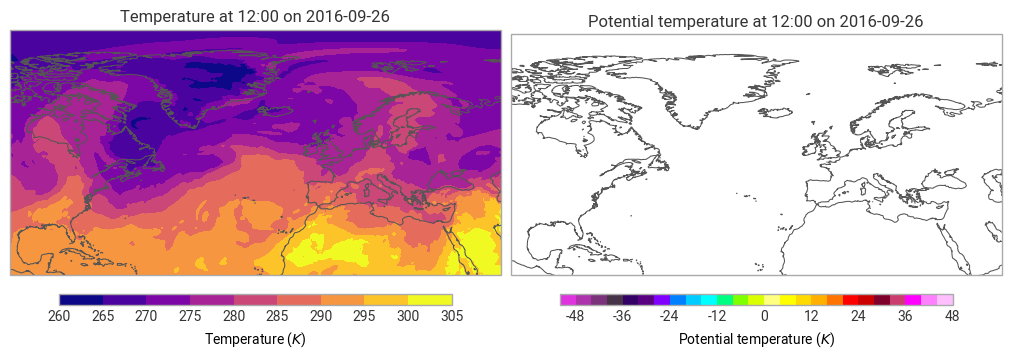

In [4]:
# select one level and step and plot input and resulting fields
t1 = ds.t.sel(pressure_level=850, valid_time="2016-09-26T12")
theta1 = theta.sel(pressure_level=850, valid_time="2016-09-26T12")
ekp.geo.plot(t1, theta1)

### Relative humidity

In [5]:
# input: temperature, specifi humidity and pressure dataarrays
r = thermo.relative_humidity_from_specific_humidity(ds.t,ds.q,ds.pressure_level)
r

<xarray.DataArray 't' (valid_time: 4, pressure_level: 3, latitude: 301,
                       longitude: 601)> Size: 17MB
dask.array<transpose, shape=(4, 3, 301, 601), dtype=float64, chunksize=(4, 3, 301, 601), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
    number          int64 8B ...
    expver          (valid_time) <U4 64B dask.array<chunksize=(4,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    %
    standard_name:                            relative_humidity

In [6]:
# set metadata
r.attrs["standard_name"] = "relative_humidity"
r.attrs["long_name"] = "Relative humidity"
r = r.rename("r")

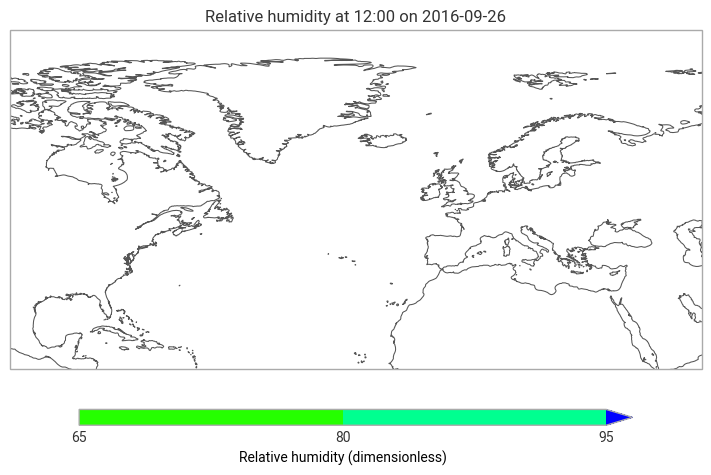

In [8]:
r1 = r.sel(pressure_level=850, valid_time="2016-09-26T12")
ekp.geo.plot(r1)

In [9]:
r1.values

array([[0.95917851, 0.95917851, 0.95917851, ..., 0.95917851, 0.95917851,
        0.95917851],
       [0.96274527, 0.96263779, 0.96272045, ..., 0.9621797 , 0.96199604,
        0.96181232],
       [0.9580729 , 0.95826922, 0.95862727, ..., 0.9591124 , 0.95926275,
        0.95909444],
       ...,
       [0.89272608, 0.91650905, 0.93065373, ..., 0.21271021, 0.2165622 ,
        0.23362789],
       [0.88746884, 0.91435458, 0.93100294, ..., 0.29850216, 0.28492515,
        0.32125412],
       [0.87291455, 0.89346032, 0.91487004, ..., 0.80169847, 0.75719002,
        0.43733251]], shape=(301, 601))